In [37]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 
import requests

%matplotlib inline 

In [38]:
def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open (filename, 'w', encoding='utf-8') as f:
            f.write(response.text)
    else:
        print('Download failed: ', response.status_code)

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
filename = "cars_model.csv"

download(url, filename)

df = pd.read_csv(filename)

# 🔢 Linear Regression: Understanding the Core Concept

In [39]:
lm = LinearRegression()
lm

LinearRegression()

## How Could "Highway-MPG" Help Us Predict Car Price?

We use **Simple Linear Regression** to see how `highway-mpg` affects `price`.

- **Predictor:** `highway-mpg` (fuel efficiency on highways)  
- **Response:** `price` (car market value)

In [40]:
x = df[['highway-mpg']]
y = df[['price']]

lm.fit(x, y)

LinearRegression()

In [41]:
yhat = lm.predict(x)
yhat[0:5]

array([[16236.50464347],
       [16236.50464347],
       [17058.23802179],
       [13771.3045085 ],
       [20345.17153508]])

## What is the value of the slope (coefficient) (a)?

In [42]:
a = lm.coef_[0][0]
a

-821.733378321925

## What is the value of the intercept (b)?

In [43]:
b = lm.intercept_[0]
b

38423.305858157386

## What is the final estimated linear model we get?

In [44]:
print(f'yhat = {a:.2f}x + {b:.2f}')

yhat = -821.73x + 38423.31


## 🔍 Linear Regression Between Engine Size and Price

In this analysis, we explore the **relationship between a car’s engine size and its price** using a **Simple Linear Regression** model.

- **Predictor (X):** `engine-size` — represents the size or capacity of the engine.  
- **Response (Y):** `price` — represents the car’s market price.

In [45]:
lm = LinearRegression()

x = df[['engine-size']]
y = df[['price']]
lm.fit(x, y)

yhat = lm.predict(x)
a = lm.coef_[0][0]
b = lm.intercept_[0]

print("=====Linear Regression between Engine-size & Price=====")
print(f'yhat = {a:.2f}x + {b:.2f}')

=====Linear Regression between Engine-size & Price=====
yhat = 166.86x + -7963.34


## 🚗 Multiple Linear Regression

In this section, we extend simple linear regression to **Multiple Linear Regression**,  
where we use **two or more predictor variables** to predict the target variable.

The general equation is:

**yhat = a_1x + a_2x + a_3x + ... + a_n + b**

From previous analysis, we found several strong predictors of car price:
- `horsepower`
- `curb-weight`
- `engine-size`
- `highway-mpg`

We’ll now build a regression model using these variables as predictors to estimate **car price**.

In [46]:
lm = LinearRegression()
x = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df[['price']]
lm.fit(x, y)

features = x.columns
equation = f"yhat = {lm.intercept_[0]:.2f}"
for coef, feat in zip(lm.coef_[0], features):
    equation += f" + ({coef:.2f} × {feat})"

print(equation)

yhat = -15806.62 + (53.50 × horsepower) + (4.71 × curb-weight) + (81.53 × engine-size) + (36.06 × highway-mpg)


## 📈 Regression Plot

For **Simple Linear Regression**, one of the best ways to visualize the model fit is by using a **regression plot**.

This plot combines:
- A **scatterplot** of the actual data points, and  
- The **fitted regression line** going through them.

It helps us visually estimate:
- The **relationship** between the two variables,  
- The **strength** of the correlation, and  
- The **direction** (positive or negative).

Let's visualize how **highway-mpg** can act as a potential predictor variable for **price**.

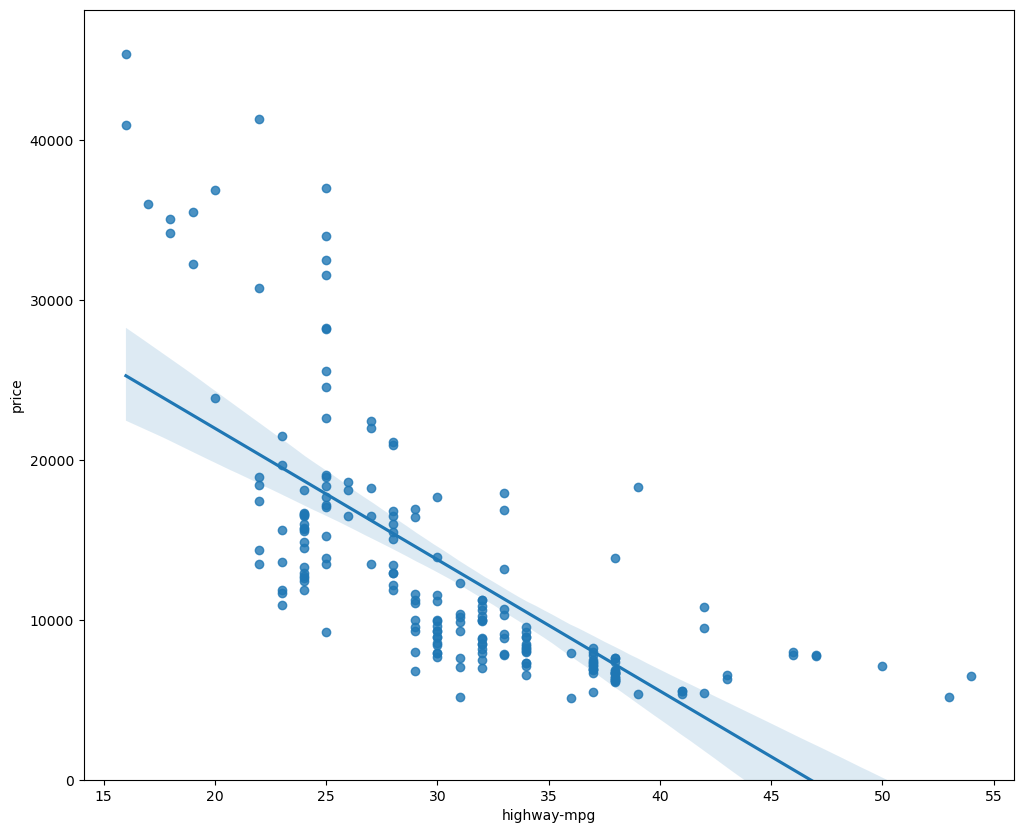

In [47]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x='highway-mpg', y='price', data=df)
plt.ylim(0,)
plt.show()

# We can see from this plot that price is negatively correlated to highway-mpg since the regression slope 
# is negative.

Let's compare this plot to the regression plot of **"peak-rpm"**.

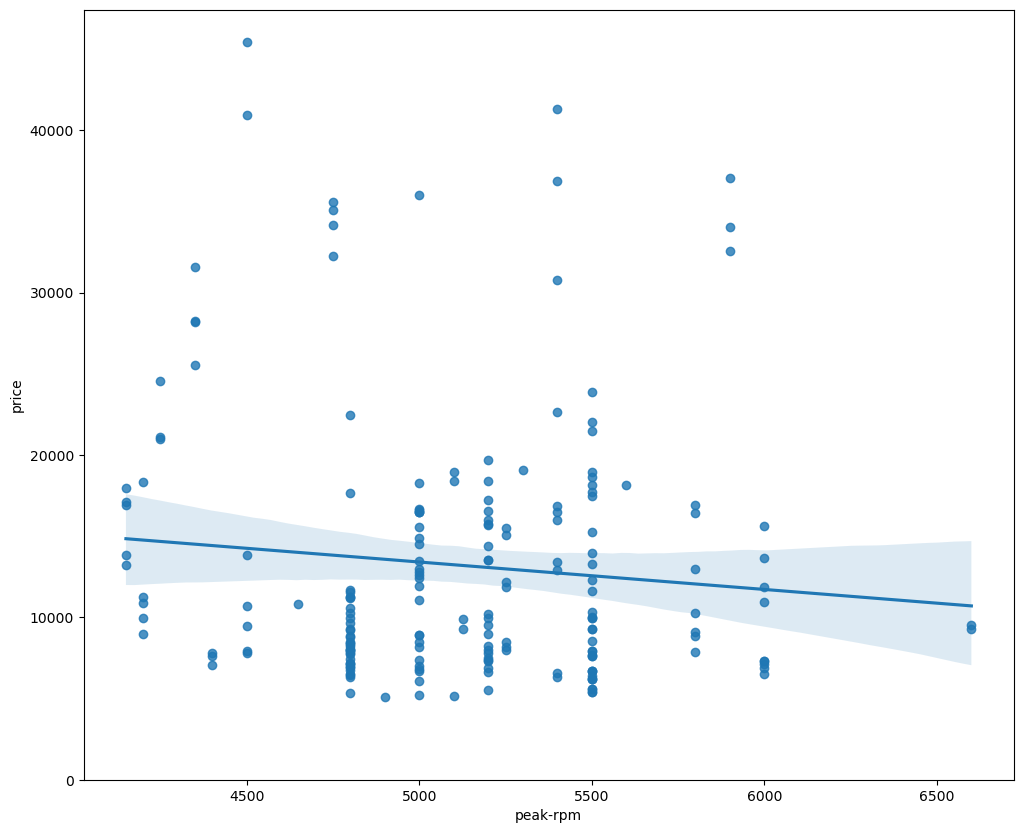

In [48]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x='peak-rpm', y='price', data=df)
plt.ylim(0,)
plt.show()

Given the regression plots above, is **"peak-rpm"** or **"highway-mpg"** more strongly correlated with **"price"**?

Hint: Use **corr()** function to verify the answer

In [51]:
correlation = df[["highway-mpg", "peak-rpm", "price"]].corr()
print(correlation)

# 	           highway-mpg	 peak-rpm	   price
# highway-mpg	1.000000	-0.058598	-0.704692
# peak-rpm	   -0.058598	 1.000000	-0.101616
# price	       -0.704692	-0.101616	 1.000000

print("=> Highway-mpg is a lot more strongly correlated with Price than Peak-rpm")

             highway-mpg  peak-rpm     price
highway-mpg     1.000000 -0.058598 -0.704692
peak-rpm       -0.058598  1.000000 -0.101616
price          -0.704692 -0.101616  1.000000
=> Highway-mpg is a lot more strongly correlated with Price than Peak-rpm


## Residual Plot

A good way to visualize the variance of the data is to use a **residual plot**.

### What is a residual?
The difference between the observed value (**y**) and the predicted value (**ŷ**) is called the **residual (e)**.


**e = y - yhat**


When we look at a regression plot, the residual is the distance from the data point to the fitted regression line.

---

### What is a residual plot?
A **residual plot** is a graph that shows:
- The **residuals** on the vertical (**y**) axis  
- The **independent variable** on the horizontal (**x**) axis  

It helps us visualize how far off our predictions are across the range of input values.

---

### What do we look for in a residual plot?
We mainly look at the **spread of the residuals**:

- ✅ **Randomly spread out residuals around the x-axis** → The linear model is appropriate.  
- ⚠️ **Patterns or systematic shapes (e.g., curves)** → The linear model may not fit the data well.

---

### Why does this matter?
Randomly distributed residuals indicate that:
- The **variance is constant** (homoscedasticity)
- The **linear assumption** holds  
→ Therefore, a **linear regression model** is a good fit for this data.


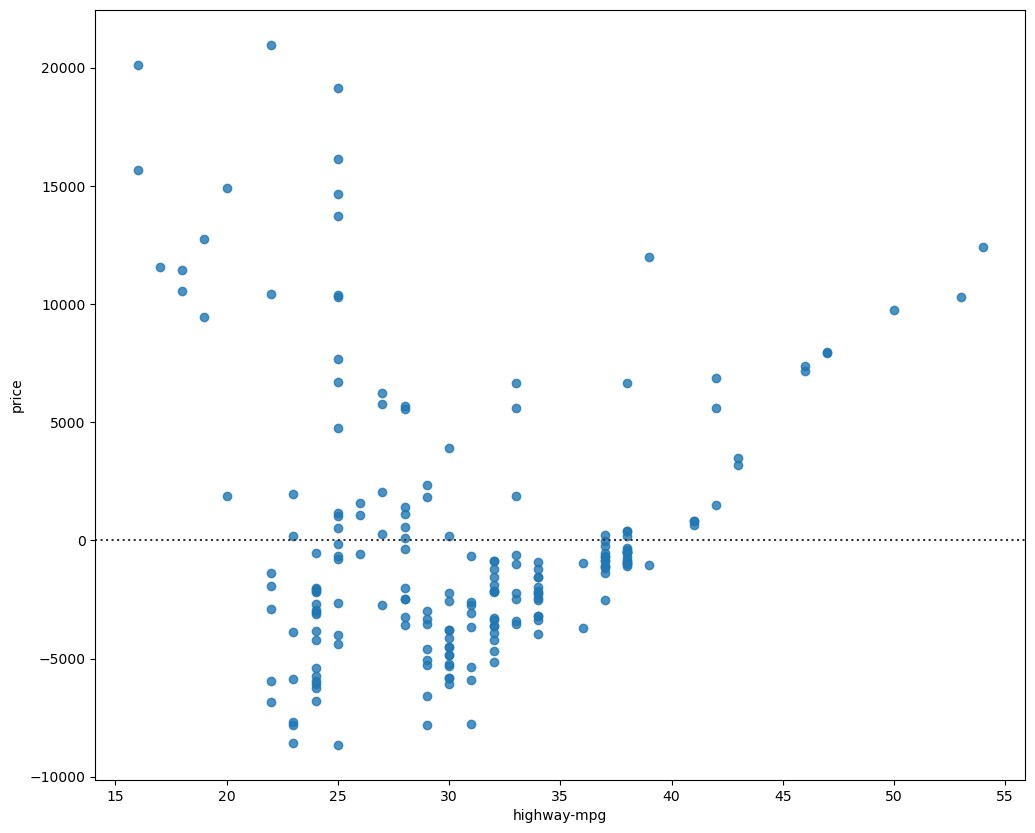

=> From the residual plot, we can see that the residuals are not randomly distributed around the x-axis.
=> This indicates that the linear regression model does not fully capture the relationship between the variables.
=> Therefore, a non-linear model may be more appropriate to represent the data more accurately.


In [55]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

print("=> From the residual plot, we can see that the residuals are not randomly distributed around the x-axis.")
print("=> This indicates that the linear regression model does not fully capture the relationship between the variables.")
print("=> Therefore, a non-linear model may be more appropriate to represent the data more accurately.")

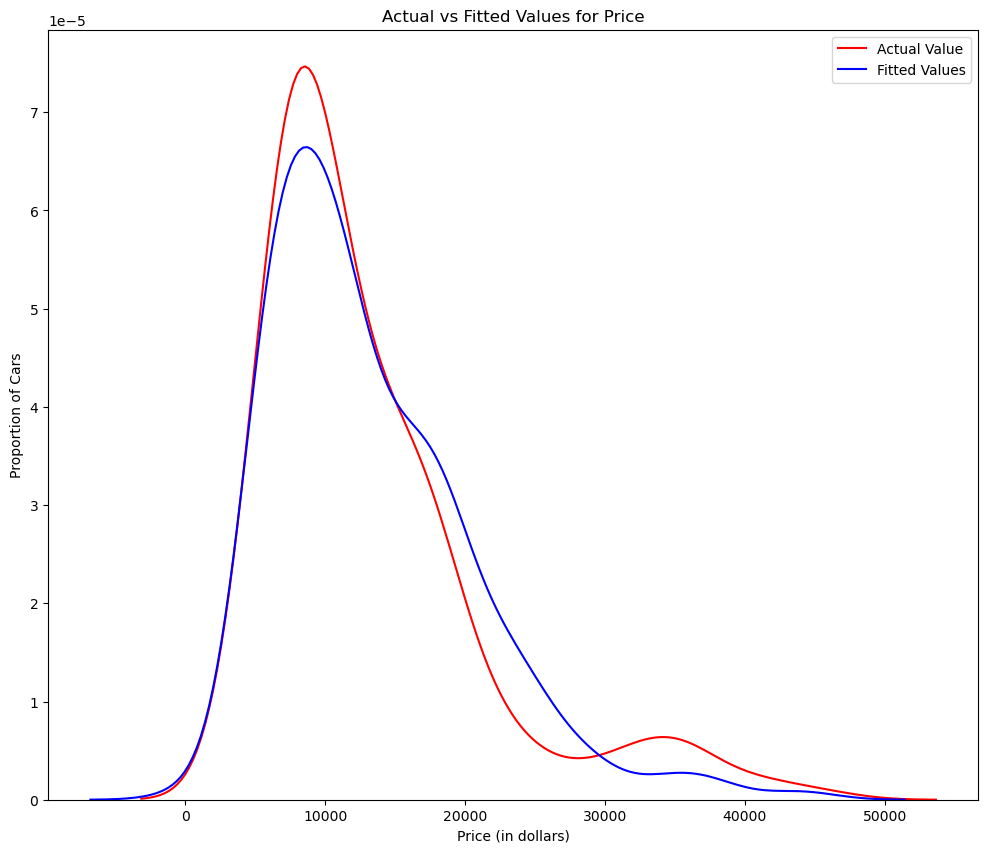

In [ ]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y_hat = lm.predict(Z)

plt.figure(figsize=(12, 10))
ax = plt.gca()

sns.kdeplot(df['price'], color="r", label="Actual Value", ax=ax)
sns.kdeplot(Y_hat.flatten(), color="b", label="Fitted Values", ax=ax)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')
plt.legend()
plt.show()